<a href="https://colab.research.google.com/github/Lyanan85/In-GameSeries/blob/venv/analise_final_14062025_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [14]:
df_inicial=pd.read_csv("/content/df_inicial.csv")
df_inicial.head(5)

,NOME,TELEFONE,UNIDADE,DENTISTA,data_e_hora,MARCADO NO DIA,COMPARECEU OU NÃO,QUEM AGENDOU,data_hora_formatada,turno
0,Francisco José Almeida da costa,85 8187-7894,Aldeota,Italo Castelo,21/02 ás 13:20,19/02/2025,NÃO COMPARECEU,Manu,2025-02-21,Tarde
1,Claudiane Gomes da Silva,85 9816-0772,Maracanaú,Francisco Robério,27/03 ás 09:00,14/03/2025,NÃO COMPARECEU,Manu,2025-03-27,Manhã
2,SANDRO SOARES DE SOUZA,85 8168-0048,Bezerra,Italo Castelo,31/03 ás 18:00,26/03/2025,NÃO COMPARECEU,Manu,2025-03-31,Noite
3,Suyanne Magalhães Paiva,85 8854-1408,Parangaba,José Irisvaldo,07/04 ás 18:30,26/03/2025,NÃO COMPARECEU,Manu,2025-04-07,Noite
4,EMANUEL DE SOUZA BATISTA,5585987619153,Messejana,Marcia,28/03 ás 09:05,26/06/2025,COMPARECEU,Natan,2025-03-28,Manhã


### QUANTIDADE DE AGENDAMENTOS POR CLÍNICA

In [15]:
df_inicial['UNIDADE'].value_counts().head(7)

,count
UNIDADE,
Parangaba,105
Bezerra,73
Aldeota,62
Messejana,58
Centro,28
Maracanaú,23
Conjunto Ceará,12


### tabela de comparecimento dentistas

In [16]:
df_comparecimento=pd.read_csv("/content/tabela comparecimento.csv")
df_comparecimento.head(10)

,DENTISTA,Aldeota,Bezerra,Bezerra De Menezes,Centro,Conjunto Ceará,Maracanaú,Messejana,Parangaba,Total
0,Italo Castelo,4,12,1,1,0,0,0,1,19
1,Monatha,2,3,0,0,0,0,0,6,11
2,Gabriela,1,1,0,0,0,0,0,6,8
3,Joana,0,0,0,7,0,0,0,0,7
4,Leticia,1,0,0,0,0,2,4,0,7
5,Carlos Veras,0,0,0,0,0,0,1,2,3
6,Allyne Fontenele,2,0,0,1,0,0,0,0,3
7,Carollyne,0,0,0,0,2,1,0,0,3
8,Laura Rodrigues,0,1,0,0,1,1,0,0,3
9,Lilian Cibele,0,1,0,0,1,1,0,0,3


In [17]:
top_dentistas = df_comparecimento.head(10)
cores = ["#FF5733", "#33FF57", "#3357FF", "#F1C40F", "cyan", "#E74C3C", "#2ECC71", "#3498DB", "#9B59B6"]

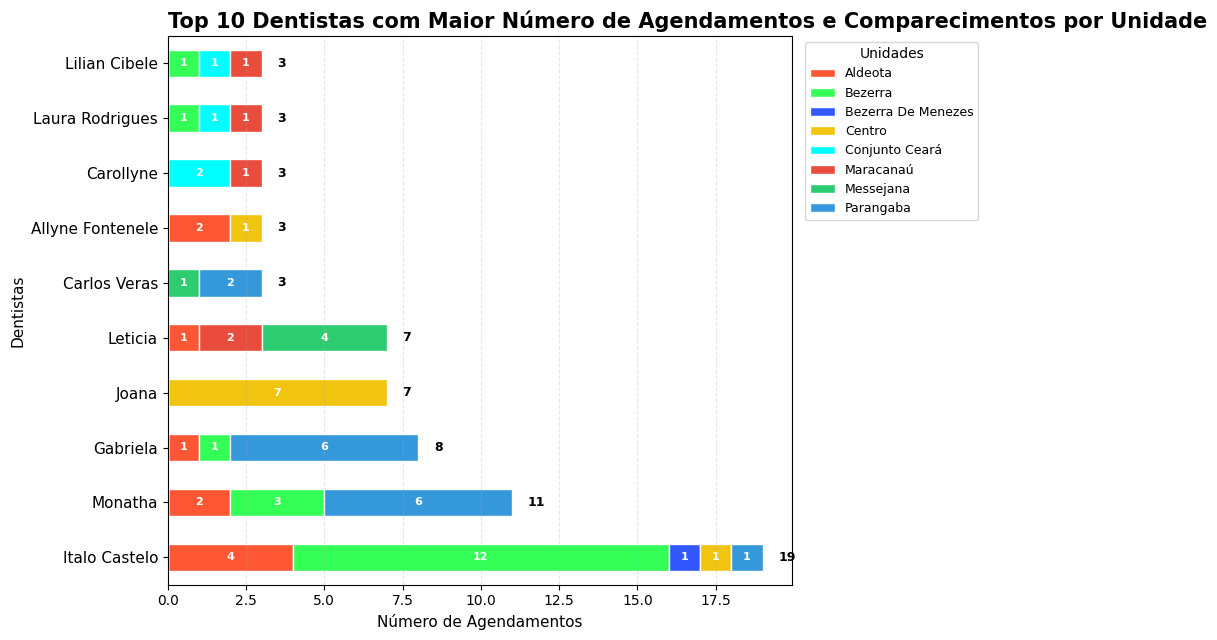

In [18]:
import matplotlib.pyplot as plt

top_dentistas = df_comparecimento.head(10)
cores = ["#FF5733", "#33FF57", "#3357FF", "#F1C40F", "cyan", "#E74C3C", "#2ECC71", "#3498DB"]

top_dentistas_sem_total = top_dentistas.drop(columns=["DENTISTA", "Total"])

fig, ax = plt.subplots(figsize=(10, 6.5))
top_dentistas_sem_total.plot(
    kind="barh",
    stacked=True,
    color=cores[:len(top_dentistas_sem_total.columns)],
    ax=ax,
    edgecolor='white'
)

ax.set_title("Top 10 Dentistas com Maior Número de Agendamentos e Comparecimentos por Unidade", fontsize=15, loc='left', weight="bold")
ax.set_xlabel("Número de Agendamentos", fontsize=11)
ax.set_ylabel("Dentistas", fontsize=11)

ax.set_yticks(range(len(top_dentistas)))
ax.set_yticklabels(top_dentistas["DENTISTA"], fontsize=11)

ax.xaxis.set_tick_params(labelsize=10)
ax.set_facecolor("white")
ax.grid(axis='x', linestyle='--', alpha=0.3)

for container in ax.containers:
    labels = [int(v) if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8, color="white", fontweight="bold")

for i, total in enumerate(top_dentistas["Total"]):
    ax.text(
        total + 0.5, i, str(int(total)),
        va="center", ha="left", fontsize=9, fontweight="bold", color="black"
    )

ax.legend(
    title="Unidades",
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()


### DENTISTAS COM MENOS COMPARECIMENTOS

In [19]:
df_faltas = pd.read_csv('/content/tabela faltas.csv', index_col=0)
df_faltas

,Aldeota,Bezerra,Centro,Conjunto Ceará,Maracanaú,Messejana,Parangaba,Total
DENTISTA,,,,,,,,
Italo Castelo,10,13,2,0,0,0,12,37
Monatha,5,0,0,0,0,0,14,19
Gabriela,1,0,0,0,0,0,9,10
Allyne Fontenele,1,0,4,1,0,2,0,8
Marina,0,0,0,0,0,6,0,6
Jessey,0,0,0,0,0,5,0,5
Lilian Cibele,0,3,0,0,1,0,1,5
Carlos Antonio Veraz,0,0,0,2,0,0,2,4
Carlos Eduardo,0,1,0,0,0,1,2,4


In [20]:
top_dentistas_faltas=df_faltas

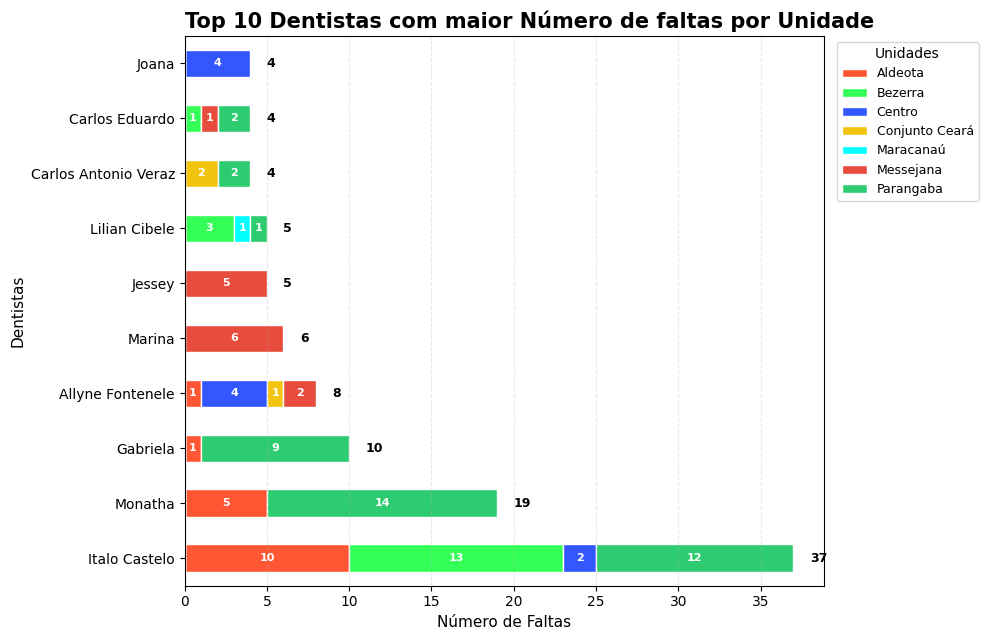

In [21]:
cores = ["#FF5733", "#33FF57", "#3357FF", "#F1C40F", "cyan", "#E74C3C", "#2ECC71", "#3498DB", "#9B59B6"]

top_dentistas_faltas_sem_total = top_dentistas_faltas.drop(columns="Total").copy()
top_dentistas_faltas_sem_total.index = top_dentistas_faltas.index  # garantir índice correto

fig, ax = plt.subplots(figsize=(10, 6.5))

top_dentistas_faltas_sem_total.plot(
    kind="barh",
    stacked=True,
    color=cores[:len(top_dentistas_faltas_sem_total.columns)],
    ax=ax,
    edgecolor="white"
)

ax.set_title("Top 10 Dentistas com maior Número de faltas por Unidade", fontsize=15, loc='left', weight="bold")
ax.set_xlabel("Número de Faltas", fontsize=11)
ax.set_ylabel("Dentistas", fontsize=11)


ax.xaxis.set_tick_params(labelsize=10)
ax.set_facecolor("white")
ax.grid(axis='x', linestyle='--', alpha=0.3)

for container in ax.containers:
    labels = [int(v) if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8,
                 color="white", fontweight="bold")

for i, total in enumerate(top_dentistas_faltas["Total"]):
    ax.text(
        total + 1, i, str(int(total)),
        va="center", ha="left", fontsize=9, fontweight="bold", color="black"
    )

# Legenda lateral
ax.legend(
    title="Unidades",
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()


### DESCOBRINDO A QUANTIDADE DE COMPARECIMENTOS POR TURNO

In [22]:

compareceu = df_inicial[df_inicial["COMPARECEU OU NÃO"] == "COMPARECEU"]

In [23]:
comparecimento_por_turno=compareceu.groupby(["DENTISTA", "UNIDADE","turno"]).size().reset_index()
tabela_comparecimento = pd.pivot_table(
    comparecimento_por_turno,
    index=['DENTISTA', 'UNIDADE'],
    columns='turno',
    values=0,
    aggfunc='sum',
    fill_value=0
)

tabela_comparecimento["Total"] = tabela_comparecimento.sum(axis=1)
tabela_comparecimento = tabela_comparecimento.sort_values(by="Total", ascending=False)



In [24]:
print("-"*50)
print("Total de comparecimentos por turno:")
print("Comparecimentos no turno da Manhã:",tabela_comparecimento["Manhã"].sum())
print("Comparecimentos no turno da Tarde:",tabela_comparecimento["Tarde"].sum())
print("Comparecimentos no turno da Noite:",tabela_comparecimento["Noite"].sum())
print("-"*50)

--------------------------------------------------
Total de comparecimentos por turno:
Comparecimentos no turno da Manhã: 39
Comparecimentos no turno da Tarde: 49
Comparecimentos no turno da Noite: 19
--------------------------------------------------


### TABELA DE VENDAS

In [25]:
df_vendas=pd.read_csv("/content/tabela_vendas_particulares.csv")
df_vendas.head()

,NOME E ID,TELEFONE,UNIDADE,DENTISTA,VALOR,PORCENTAGEM,PROCEDIMENTO,DATA E HORA,Total,QUEM AGENDOU
0,5047040-ERICA DA SILVA VASCONCELOS,85989946630,Maracanaú,Leticia,1500.0,"1,00%",PRÓTESE FLEX,28/03 ÁS 08:20,"R$ 15,00",Manu
1,5058415-Mateus Cruz Soares,85981508303,Messejana,Marina,80.0,1%,Contrato - Orto,31/03 ás 10:00,"R$ 0,80",Natan
2,4664590 - GEICIANE NASCIMENTO,85988667658,Bezerra,Maria Do Socorro,240.0,"1,00%",LIMPEZA II,29/03 ás 10:10,"R$ 2,40",Natan
3,5058469 - MARIA ISABEL DE SOUSA BRITO,85996877120,Bezerra,Vanilde Belo Aragão,125.0,1%,Manutenção ortodontico,31/03/2025 14:20,"R$ 1,25",Stephanie
4,5058690 - TALITA PINHEIRO VITORINO,85988806704,Messejana,Carlos Eduardo,200.0,"1,00%",EXODONTIA,01/04 ÁS 17:30,"R$ 2,00",Manu


### IREMOS REALIZAR UMA PEQUENA LIMPEZA NOS DADOS

In [26]:
def limpar_valor(valor):
    if isinstance(valor, str):
        valor = valor.replace("R$", "").replace(".", "").replace(",", ".").strip()
    return float(valor)

df_vendas[" VALOR "] = df_vendas[" VALOR "].apply(limpar_valor)
df_vendas["TOTAL"] = df_vendas["Total"].apply(limpar_valor)



KeyError: ' VALOR '

### QUANTIDADE DE FECHAMENTO POR DENTISTAS

In [27]:
df_vendas["DENTISTA"].value_counts().sort_values(ascending=False)

,count
DENTISTA,
Leticia,7
Gabriela,5
Joana,5
Italo Castelo,4
Silvio,4
Ana Mylena,3
Jessey,3
Allyne Fontenele,3
Monatha,3


### IREMOS VERIFICAR AS VENDAS DO DR.ITALO

In [28]:
df_vendas.loc[df_vendas["DENTISTA"]=="Italo Castelo"]

,NOME E ID,TELEFONE,UNIDADE,DENTISTA,VALOR,PORCENTAGEM,PROCEDIMENTO,DATA E HORA,Total,QUEM AGENDOU
12,5022912 - ROSA DOMICILIA MOREIRA ARAGAO DE LIMA,85999924974,Aldeota,Italo Castelo,240.0,"1,00%",MANUTENÇÃO DE PRÓTESE,05/04 ÁS 10:05,"R$ 2,40",Manu
16,5060705-MARIA IOLINDA CARDOSO COSTA,85989407212,Bezerra,Italo Castelo,1500.0,"1,00%",IMPLANTE ESPECIAL UD 37,12/04 ÁS 08:20,"R$ 15,00",Manu
36,5062510-MARIO GLADSTON DA SILVA FIDELES,85994132328,Bezerra,Italo Castelo,260.0,"1,00%",MANUTENÇÃO IMPLANTE,10/05 ás 11:20,"R$ 2,60",Stephanie
43,4657298 - ELIDIANE LOURENCO DOS SANTOS,85)98929.3995,Bezerra,Italo Castelo,1500.0,"1,00%",IMPLANTE ESPECIAL UD 21,20/05 ás 09:00,"R$ 15,00",Natan


### VERIFICANDO AS VENDAS DA DRA.LETICIA

In [29]:
df_vendas.loc[df_vendas["DENTISTA"]=="Leticia"]

,NOME E ID,TELEFONE,UNIDADE,DENTISTA,VALOR,PORCENTAGEM,PROCEDIMENTO,DATA E HORA,Total,QUEM AGENDOU
0,5047040-ERICA DA SILVA VASCONCELOS,85989946630,Maracanaú,Leticia,1500.0,"1,00%",PRÓTESE FLEX,28/03 ÁS 08:20,"R$ 15,00",Manu
22,5060030 - CICERO RAPHAEL FEITOZA,34991122148,Maracanaú,Leticia,380.0,"1,00%",REMOÇÃO DE SISO,16/04 ÁS 17:00,"R$ 3,80",Stephanie
29,5047633 - PATRICIA COSTA FERNANDES,85996847248,Messejana,Leticia,1600.0,"1,00%",COROA TOTAL METALO CERÂMICA,17/05 ÁS 15;00,"R$ 16,00",Stephanie
35,5062887 - ALINE SILVA ALVES,85987736660,Messejana,Leticia,750.0,"1,00%",CLAREAMENTO DENTAL MISTO,08/05 ás 16:40,"R$ 7,50",Manu
41,5063490 - MARIA LENIR SANTOS DA SILVA,85987787899,Messejana,Leticia,1600.0,"1,00%",PRÓTESE PARCIAL REMOVÍVEL COM GRAMPOS BILATERAL,15/05 ás 15:20,"R$ 16,00",Manu
44,5053380-VALDOMIRA TINTINO DE OLIVEIRA,85996598037,Aldeota,Leticia,427.5,"1,00%",RECONSTRUÇÃO TIPO V UD 36,24/05 ás 09:20,"R$ 4,27",Manu
50,5063468-VINICIUS RIBEIRO RODRIGUES,85998300400,Messejana,Leticia,349.0,"1,00%",limpeza e restauração,15/05 ás 14;00,"R$ 3,49",Manu


### VERIFICANDO AS VENDAS DA DRA.MONATHA

In [30]:
df_vendas.loc[df_vendas["DENTISTA"]=="Monatha"]

,NOME E ID,TELEFONE,UNIDADE,DENTISTA,VALOR,PORCENTAGEM,PROCEDIMENTO,DATA E HORA,Total,QUEM AGENDOU
25,5061120-SILVA MARIA DE SOUSA OLIVEIRA,85987021567,Parangaba,Monatha,1725.0,"1,00%",PRÓTESE FLEX,25/04 ÁS 14:15,"R$ 17,65",Manu
34,5053699-ALICE DE PAIVA VIANA,85999162737,Parangaba,Monatha,770.0,"1,00%",PLACA DE MORDIDA MIORRELAXANTE,07/05 ás 18;00,"R$ 7,70",Manu
62,5066143-IGOR BARBOSA DA SILVA,85987556236,Parangaba,Monatha,115.0,"1,00%",RASPAGEM SUPRA-GENGIVA,13/06 ás 16:00,"R$ 1,15",Manu


### ANALISANDO O DF FINAL


In [31]:
df_final=pd.read_csv("/content/df_final.csv")
df_final

,DENTISTA,Fechamentos,Total_Produzido,Agendamentos_comparecidos,Agendamentos_faltosos,Agendamentos_totais
0,Leticia,7,6606.5,7.0,3,10.0
1,Gabriela,5,4820.0,8.0,10,18.0
2,Italo Castelo,4,3500.0,19.0,37,56.0
3,Monatha,3,2610.0,11.0,19,30.0
4,Joana,5,1775.0,7.0,4,11.0
5,Lilian Cibele,3,1695.0,3.0,5,8.0
6,Allyne Fontenele,3,1480.0,3.0,8,11.0
7,Thais Carolina,1,1260.0,2.0,4,6.0
8,Lennilton,2,750.0,2.0,1,3.0
9,Carlos Eduardo,2,700.0,1.0,4,5.0


### VERIFICANDO VALOR DE VENDAS - POR FALTAS DE COMPARECIMENTO

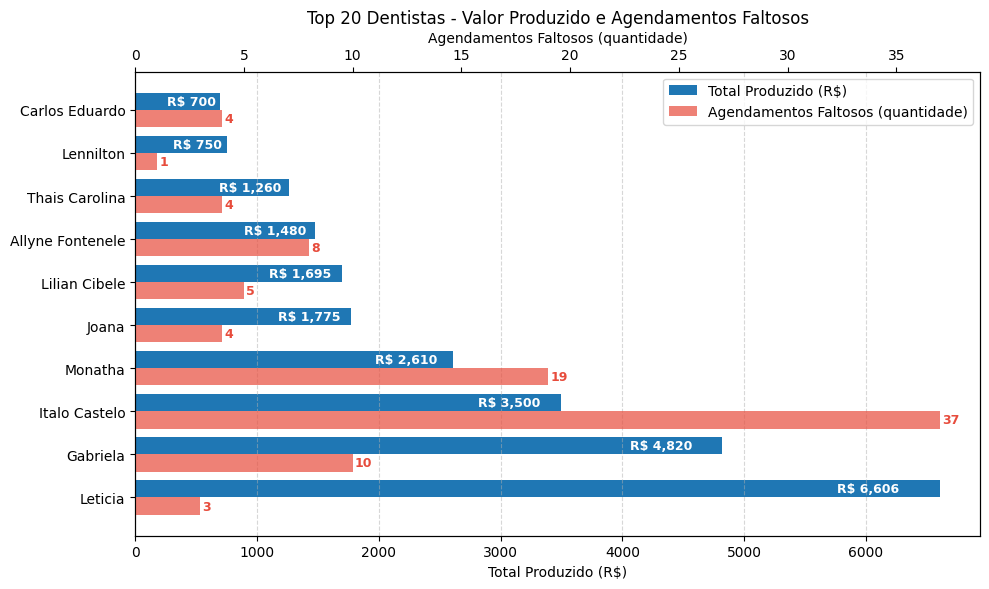

In [32]:
top20 = df_final.sort_values(by='Total_Produzido', ascending=False).head(10).copy()
top20 = top20[::-1]
fig, ax1 = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(top20))

bar_width = 0.4

bars_valor = ax1.barh(y_pos - bar_width/2, top20['Total_Produzido'], height=bar_width, color='#1f77b4', label='Total Produzido (R$)')

ax1.set_xlabel('Total Produzido (R$)')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top20['DENTISTA'])
ax1.invert_yaxis()
ax1.grid(axis='x', linestyle='--', alpha=0.5)
ax1.set_title('Top 20 Dentistas - Valor Produzido e Agendamentos Faltosos')

ax2 = ax1.twiny()

bars_faltosos = ax2.barh(y_pos + bar_width/2, top20['Agendamentos_faltosos'], height=bar_width, color='#e74c3c', alpha=0.7, label='Agendamentos Faltosos (quantidade)')

ax2.set_xlabel('Agendamentos Faltosos (quantidade)')

for bar in bars_valor:
    width = bar.get_width()
    ax1.text(width - width*0.05, bar.get_y() + bar.get_height()/2, f'R$ {width:,.0f}', va='center', ha='right', color='white', fontweight='bold', fontsize=9)

for bar in bars_faltosos:
    width = bar.get_width()
    if width > 0:
        ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center', ha='left', color='#e74c3c', fontweight='bold', fontsize=9)


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right', bbox_to_anchor=(1, 1), ncol=1)

plt.tight_layout()
plt.show()


## VAMOS VERIFICAR OS DENTISTAS COM MAIOR TAXA DE FECHAMENTO

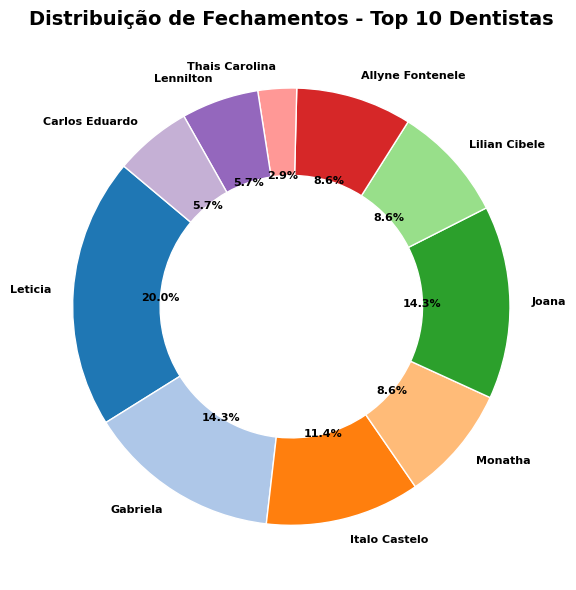

In [33]:
top10_fechamentos = df_final.head(10)
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20.colors

wedges, texts, autotexts = ax.pie(
    top10_fechamentos["Fechamentos"],
    labels=top10_fechamentos["DENTISTA"],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'},
    textprops={'fontsize': 8, 'weight': 'bold', 'color': 'black'}
)

ax.set_title("Distribuição de Fechamentos - Top 10 Dentistas", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### TAXA DE FECHAMENTO DE PROCEDIMENTOS INDIVIDUAIS

In [34]:
df_final["Taxa_Fechamento (%)"]=(df_final["Fechamentos"]/df_final["Agendamentos_comparecidos"])*100
df_final["Taxa_Fechamento (%)"]=df_final["Taxa_Fechamento (%)"].round(1)
tabela_taxa_fechamento = df_final.head(10)[["DENTISTA", "Fechamentos","Agendamentos_comparecidos", "Agendamentos_totais", "Taxa_Fechamento (%)"]]
tabela_taxa_fechamento

,DENTISTA,Fechamentos,Agendamentos_comparecidos,Agendamentos_totais,Taxa_Fechamento (%)
0,Leticia,7,7.0,10.0,100.0
1,Gabriela,5,8.0,18.0,62.5
2,Italo Castelo,4,19.0,56.0,21.1
3,Monatha,3,11.0,30.0,27.3
4,Joana,5,7.0,11.0,71.4
5,Lilian Cibele,3,3.0,8.0,100.0
6,Allyne Fontenele,3,3.0,11.0,100.0
7,Thais Carolina,1,2.0,6.0,50.0
8,Lennilton,2,2.0,3.0,100.0
9,Carlos Eduardo,2,1.0,5.0,200.0


A Dra. Leticia tem sido um verdadeiro destaque desde sua chegada à equipe. Com 10 agendamentos totais e 7 comparecimentos, ela converteu todos os pacientes que compareceram, alcançando uma taxa de 100% de fechamento. Esse desempenho a coloca entre os nomes mais promissores da clínica, com resultados que chamam atenção não só pela eficiência, mas pela consistência.

Seu volume de fechamentos já ultrapassa outros profissionais com número maior de atendimentos. Por exemplo, o Dr. Italo Castelo teve 19 comparecimentos e fechou apenas 4 contratos, o que representa uma taxa de 21,1%. Já nomes mais consolidados da área estética, como Gabriela e Joana, apresentaram taxas de 62,5% e 71,4%, respectivamente, mas ainda abaixo do impacto proporcional que Leticia vem gerando.

Vale destacar também que outras profissionais com taxa de 100%, como Lilian Cibele, Allyne Fontenele e Lennilton, atuaram em volumes bem menores — todas com até 3 comparecimentos. O caso do Dr. Carlos Eduardo é um ponto fora da curva: mesmo com apenas 1 comparecimento, ele computou 2 fechamentos, resultando em uma taxa artificialmente elevada de 200%.

Leticia, por outro lado, alia alta taxa de conversão com um volume significativo de agendamentos. E se considerarmos a variedade de procedimentos que ela realiza — que incluem áreas estética, clínica e reabilitadora — fica claro que ela não apenas converte, como também gera alto valor por atendimento.

Com esse equilíbrio entre produtividade, versatilidade e performance, é seguro afirmar que Leticia já desponta como uma das principais apostas da clínica para os próximos ciclos. Ela não apenas entrega resultados — ela está ajudando a redefinir o padrão de excelência da equipe.

In [35]:
df_vendas.columns = df_vendas.columns.str.strip()  #das colunas
df_vendas["VALOR"] = pd.to_numeric(df_vendas["VALOR"], errors="coerce")

lucro_por_unidade = (
    df_vendas.groupby("UNIDADE")["VALOR"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
lucro_por_unidade.columns = ["UNIDADE", "Lucro Total (R$)"]
lucro_por_unidade


,UNIDADE,Lucro Total (R$)
0,Parangaba,8280.0
1,Bezerra,6300.0
2,Messejana,6259.0
3,Centro,3155.0
4,Maracanaú,2595.0
5,Aldeota,2225.5
6,Conjunto Ceará,965.0


A Parangaba está mandando muito bem, puxando a fila com um lucro total de R$ 8.280. Dá pra ver que lá o movimento está forte e os resultados aparecem no caixa.

Em seguida, as unidades de Bezerra e Messejana estão quase no mesmo patamar, com algo em torno de R$ 6.300 cada uma. Isso mostra que elas também estão indo muito bem, com bastante atendimento e bons resultados.

Depois vem o Centro, com pouco mais de R$ 3.000, e a Maracanaú, que fatura uns R$ 2.600. Essas unidades ainda têm espaço para crescer, mas já têm uma boa base de clientes.

Por fim, as clínicas de Aldeota e Conjunto Ceará aparecem com números menores, principalmente o Conjunto Ceará, que está com menos de mil reais de lucro. Isso indica que talvez seja hora de pensar em estratégias para atrair mais pacientes por lá.

No geral, a gente consegue ver claramente onde as coisas estão andando bem e onde dá pra investir um pouco mais para melhorar.

/tmp/ipython-input-36-158628572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


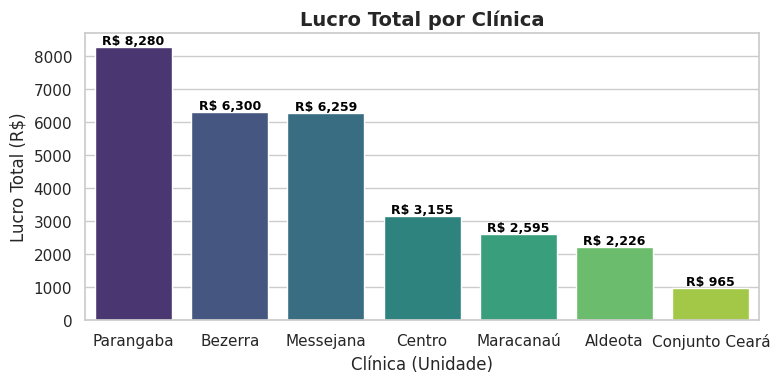

In [36]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 4))
barplot = sns.barplot(
    data=lucro_por_unidade,
    x="UNIDADE",
    y="Lucro Total (R$)",
    palette="viridis"
)

plt.title("Lucro Total por Clínica", fontsize=14, weight="bold")
plt.xlabel("Clínica (Unidade)", fontsize=12)
plt.ylabel("Lucro Total (R$)", fontsize=12)

plt.xticks(rotation=0, ha="center")

for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'R$ {height:,.0f}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color='black', weight='bold')

plt.tight_layout()
plt.show()


In [37]:

df_vendas.columns = df_vendas.columns.str.strip()

df_vendas["VALOR"] = pd.to_numeric(df_vendas["VALOR"], errors="coerce")

lucro_por_dentista_unidade = (
    df_vendas.groupby(["UNIDADE", "DENTISTA"])["VALOR"]
    .sum()
    .reset_index()
)

idx = lucro_por_dentista_unidade.groupby("UNIDADE")["VALOR"].idxmax()
top_dentistas_por_unidade = lucro_por_dentista_unidade.loc[idx].reset_index(drop=True)

top_dentistas_por_unidade.columns = ["UNIDADE", "DENTISTA", "Lucro Total (R$)"]

top_dentistas_por_unidade


,UNIDADE,DENTISTA,Lucro Total (R$)
0,Aldeota,Thais Carolina,1260.0
1,Bezerra,Italo Castelo,3260.0
2,Centro,Joana,1775.0
3,Conjunto Ceará,Lilian Cibele,365.0
4,Maracanaú,Leticia,1880.0
5,Messejana,Leticia,4299.0
6,Parangaba,Gabriela,4695.0


/tmp/ipython-input-38-4226945048.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


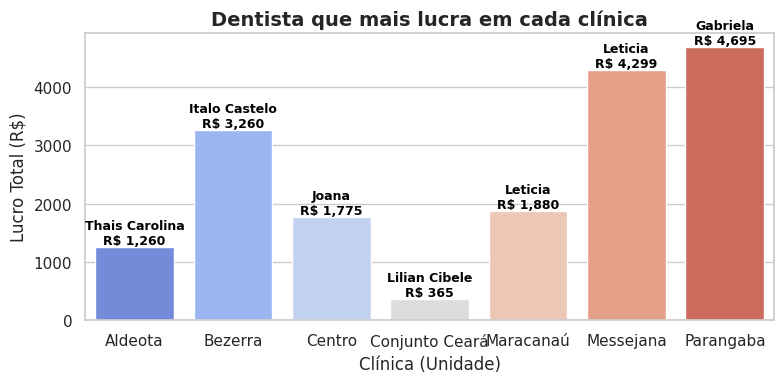

In [38]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 4))
barplot = sns.barplot(
    data=top_dentistas_por_unidade,
    x="UNIDADE",
    y="Lucro Total (R$)",
    palette="coolwarm"
)

plt.title("Dentista que mais lucra em cada clínica", fontsize=14, weight="bold")
plt.xlabel("Clínica (Unidade)", fontsize=12)
plt.ylabel("Lucro Total (R$)", fontsize=12)

plt.xticks(rotation=0, ha="center")  # Texto reto, horizontal

# Anotar o nome do dentista em cima da barra
for p, dentista in zip(barplot.patches, top_dentistas_por_unidade["DENTISTA"]):
    height = p.get_height()
    barplot.annotate(f'{dentista}\nR$ {height:,.0f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color='black', weight='bold')

plt.tight_layout()
plt.show()

Agora, falando da Letícia, que é destaque em duas unidades, ela merece um destaque especial: em Maracanaú, Letícia acumulou R$ 1.880 de lucro,  e em Messejana ela realmente se destacou, com incríveis R$ 4.299! Isso mostra que ela tem uma clientela fiel e sabe como transformar atendimentos em resultados reais para as clínicas.

em Parangaba, a Gabriela lidera com R$ 4.695, mostrando que é uma das profissionais que mais geram valor por lá, contribuindo muito para o sucesso da unidade.

###  iremos analisar um padrão entre datas e turnos

In [39]:
turno_data_vendas=pd.read_csv("/content/dentista_turno_data.csv")
turno_data_vendas

,DENTISTA,UNIDADE,VALOR,PROCEDIMENTO,data,Turno,dia_semana
0,Leticia,Maracanaú,1500.0,PRÓTESE FLEX,2025-03-28,Manhã,Sexta-feira
1,Marina,Messejana,80.0,Contrato - Orto,2025-03-31,Manhã,Segunda-feira
2,Maria Do Socorro,Bezerra,240.0,LIMPEZA II,2025-03-29,Manhã,Sábado
3,Vanilde Belo Aragão,Bezerra,125.0,Manutenção ortodontico,2025-03-31,Tarde,Segunda-feira
4,Carlos Eduardo,Messejana,200.0,EXODONTIA,2025-04-01,Tarde,Terça-feira
...,...,...,...,...,...,...,...
59,Fabio,Messejana,140.0,limpeza Odontopediatrica,2025-06-10,Manhã,Terça-feira
60,Lennilton,Messejana,400.0,RECONSTRUÇÃO TIPO V UD 21,2025-06-03,Noite,Terça-feira
61,Jessey,Parangaba,220.0,"LIMPEZA II - TARTARECTOMIA , PROFILAXIA",2025-06-12,Manhã,Quinta-feira
62,Monatha,Parangaba,115.0,RASPAGEM SUPRA-GENGIVA,2025-06-13,Tarde,Sexta-feira


VENDAS ACIMA DE 1000 REAIS

In [40]:
vendas_relevantes=turno_data_vendas.loc[turno_data_vendas[" VALOR "]>=1000].copy()
vendas_relevantes

,DENTISTA,UNIDADE,VALOR,PROCEDIMENTO,data,Turno,dia_semana
0,Leticia,Maracanaú,1500.0,PRÓTESE FLEX,2025-03-28,Manhã,Sexta-feira
16,Italo Castelo,Bezerra,1500.0,IMPLANTE ESPECIAL UD 37,2025-04-12,Manhã,Sábado
25,Monatha,Parangaba,1725.0,PRÓTESE FLEX,2025-04-25,Tarde,Sexta-feira
29,Leticia,Messejana,1600.0,COROA TOTAL METALO CERÂMICA,2025-05-17,Tarde,Sábado
41,Leticia,Messejana,1600.0,PRÓTESE PARCIAL REMOVÍVEL COM GRAMPOS BILATERAL,2025-05-15,Tarde,Quinta-feira
43,Italo Castelo,Bezerra,1500.0,IMPLANTE ESPECIAL UD 21,2025-05-20,Manhã,Terça-feira
54,Gabriela,Parangaba,3800.0,retratamento de 2 canais e 1 coroa metalo,2025-06-12,Tarde,Quinta-feira
55,Allyne Fontenele,Centro,1380.0,RESTAURAÇÃO INLAY E ONLAY (ARTGLASS/SOLIDEX) 4...,2025-06-12,Manhã,Quinta-feira
56,Thais Carolina,Aldeota,1260.0,"RASPAGEM SUB-GENGIVAL,ALISAMENTO RADICULAR",2025-05-21,Tarde,Quarta-feira


In [41]:
periodo_fechamento=turno_data_vendas["Turno"].value_counts().sort_index()
periodo_fechamento

,count
Turno,
Manhã,31
Noite,5
Sem Horário,1
Tarde,27


In [42]:
fechamentos_turno_data=turno_data_vendas.groupby(["Turno", "dia_semana"]).size().reset_index(name='Fechamentos').sort_values(by="Fechamentos",ascending=False)
fechamentos_turno_data

,Turno,dia_semana,Fechamentos
4,Manhã,Sábado,10
11,Tarde,Sexta-feira,10
3,Manhã,Sexta-feira,8
9,Tarde,Quinta-feira,6
5,Manhã,Terça-feira,4
0,Manhã,Quarta-feira,4
13,Tarde,Terça-feira,4
8,Tarde,Quarta-feira,4
7,Noite,Terça-feira,3
1,Manhã,Quinta-feira,3


# Analisando os dados acima
### Como podemos verificar acima, temos um fechamento aos sábados a tarde, mas não atendemos aos sábados

In [43]:
filtro_1=(turno_data_vendas["dia_semana"]=="Sábado") & (turno_data_vendas["Turno"]=="Tarde")
turno_data_vendas[filtro_1]

,DENTISTA,UNIDADE,VALOR,PROCEDIMENTO,data,Turno,dia_semana
29,Leticia,Messejana,1600.0,COROA TOTAL METALO CERÂMICA,2025-05-17,Tarde,Sábado


# VERIFICANDO PLANILHA VENDAS
### Com o objetivo de descobrirmos o motivo desse agendamento

In [44]:
filtro_2=df_vendas[df_vendas["DATA E HORA"].str.contains("17/05",na=False)]
filtro_2


,NOME E ID,TELEFONE,UNIDADE,DENTISTA,VALOR,PORCENTAGEM,PROCEDIMENTO,DATA E HORA,Total,QUEM AGENDOU
29,5047633 - PATRICIA COSTA FERNANDES,85996847248,Messejana,Leticia,1600.0,"1,00%",COROA TOTAL METALO CERÂMICA,17/05 ÁS 15;00,"R$ 16,00",Stephanie


# Conclusão
### como podemos verificar acima, foi um erro de marcação na planilha original
Dra.Leticia pegou um orçamento passado ao Dr.João Victor e realizou a venda e o procedimento

# Agora vamos corrigir essa linhan problemática para ele se enquadrar aos padrões de dados!!!

Será criado uma mascara para a filtragem, para podermos corrigir a linha problemática

In [45]:
turno_data_vendas.head()

,DENTISTA,UNIDADE,VALOR,PROCEDIMENTO,data,Turno,dia_semana
0,Leticia,Maracanaú,1500.0,PRÓTESE FLEX,2025-03-28,Manhã,Sexta-feira
1,Marina,Messejana,80.0,Contrato - Orto,2025-03-31,Manhã,Segunda-feira
2,Maria Do Socorro,Bezerra,240.0,LIMPEZA II,2025-03-29,Manhã,Sábado
3,Vanilde Belo Aragão,Bezerra,125.0,Manutenção ortodontico,2025-03-31,Tarde,Segunda-feira
4,Carlos Eduardo,Messejana,200.0,EXODONTIA,2025-04-01,Tarde,Terça-feira


In [46]:
# Parte Responsável por localizar a linha problemática
mascara=(turno_data_vendas["data"]=="2025-05-17")&(turno_data_vendas["Turno"]=="Tarde")&(turno_data_vendas["dia_semana"]=="Sábado")
# Parte Responsável por reescrever a linha problemática
turno_data_vendas.loc[mascara,"Turno"]="Manhã"


In [47]:
turno_data_vendas

,DENTISTA,UNIDADE,VALOR,PROCEDIMENTO,data,Turno,dia_semana
0,Leticia,Maracanaú,1500.0,PRÓTESE FLEX,2025-03-28,Manhã,Sexta-feira
1,Marina,Messejana,80.0,Contrato - Orto,2025-03-31,Manhã,Segunda-feira
2,Maria Do Socorro,Bezerra,240.0,LIMPEZA II,2025-03-29,Manhã,Sábado
3,Vanilde Belo Aragão,Bezerra,125.0,Manutenção ortodontico,2025-03-31,Tarde,Segunda-feira
4,Carlos Eduardo,Messejana,200.0,EXODONTIA,2025-04-01,Tarde,Terça-feira
...,...,...,...,...,...,...,...
59,Fabio,Messejana,140.0,limpeza Odontopediatrica,2025-06-10,Manhã,Terça-feira
60,Lennilton,Messejana,400.0,RECONSTRUÇÃO TIPO V UD 21,2025-06-03,Noite,Terça-feira
61,Jessey,Parangaba,220.0,"LIMPEZA II - TARTARECTOMIA , PROFILAXIA",2025-06-12,Manhã,Quinta-feira
62,Monatha,Parangaba,115.0,RASPAGEM SUPRA-GENGIVA,2025-06-13,Tarde,Sexta-feira


In [48]:
# Parte Responsável por reorganizar os dados para podermos plotar em um gráfico
fechamentos_turno_data=turno_data_vendas.groupby(["Turno","dia_semana"]).size().reset_index(name="Fechamentos").sort_values(by="Fechamentos",ascending=False)
fechamentos_turno_data

,Turno,dia_semana,Fechamentos
4,Manhã,Sábado,11
11,Tarde,Sexta-feira,10
3,Manhã,Sexta-feira,8
9,Tarde,Quinta-feira,6
0,Manhã,Quarta-feira,4
12,Tarde,Terça-feira,4
8,Tarde,Quarta-feira,4
5,Manhã,Terça-feira,4
1,Manhã,Quinta-feira,3
7,Noite,Terça-feira,3


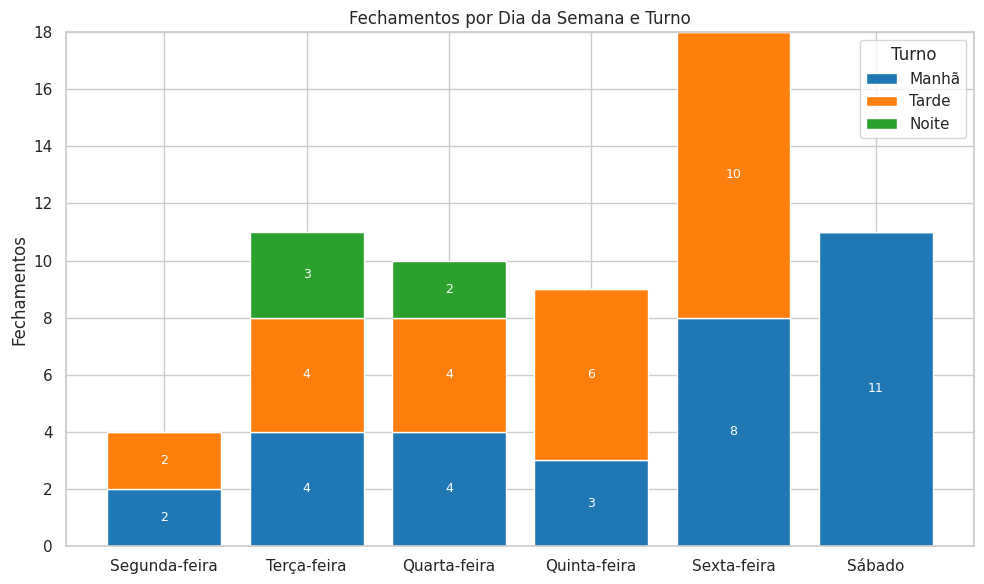

In [49]:
dias_ordem = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado']
turnos_ordem = ['Manhã', 'Tarde', 'Noite']
cores = {'Manhã': '#1f77b4', 'Tarde': '#ff7f0e', 'Noite': '#2ca02c'}

# Pivotar os dados
pivot_df = fechamentos_turno_data.pivot_table(
    index='dia_semana',
    columns='Turno',
    values='Fechamentos',
    aggfunc='sum',
    fill_value=0
).reindex(dias_ordem)[turnos_ordem]  # Reordena as colunas também

# Preparar o gráfico
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(dias_ordem))
bottom = np.zeros(len(dias_ordem))  # Base para empilhamento

# Plotar com laço for
for turno in turnos_ordem:
    valores = pivot_df[turno].values
    bars = ax.bar(x, valores, bottom=bottom, color=cores[turno], label=turno)

    # Adicionar rótulos em cada barra
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{int(bar.get_height())}',
                    ha='center', va='center', fontsize=9, color='white')

    bottom += valores  # Atualiza base para a próxima camada

# Configurações finais
ax.set_xticks(x)
ax.set_xticklabels(dias_ordem)
ax.set_ylabel('Fechamentos')
ax.set_title('Fechamentos por Dia da Semana e Turno')
ax.legend(title='Turno')
plt.tight_layout()
plt.show()